In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset loading

In [2]:
!pip install pyloess

In [3]:
import numpy as np
import pandas as pd
from pyloess import loess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [4]:
path = '/content/drive/MyDrive/2025_2026/PSM/Regression_2/state_x77.csv'

state_data = pd.read_csv(path, index_col = 0)
state_data.head(10)

,Population,Income,Illiteracy,Life Exp,Murder,HS Grad
Alabama,3615,3624,2.1,69.05,15.1,41.3
Alaska,365,6315,1.5,69.31,11.3,66.7
Arizona,2212,4530,1.8,70.55,7.8,58.1
Arkansas,2110,3378,1.9,70.66,10.1,39.9
California,21198,5114,1.1,71.71,10.3,62.6
Colorado,2541,4884,0.7,72.06,6.8,63.9
Connecticut,3100,5348,1.1,72.48,3.1,56.0
Delaware,579,4809,0.9,70.06,6.2,54.6
Florida,8277,4815,1.3,70.66,10.7,52.6
Georgia,4931,4091,2.0,68.54,13.9,40.6


Loess regression

In [5]:
X = state_data['Life Exp'].values
Y = state_data['Murder'].values

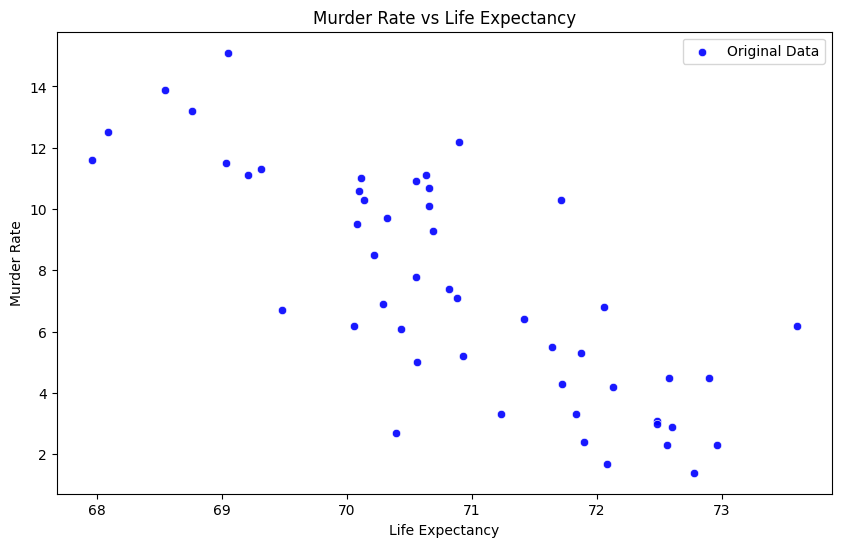

In [6]:
# Plot the original data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=Y, label='Original Data', color='blue', alpha=0.9)
plt.xlabel('Life Expectancy')
plt.ylabel('Murder Rate')
plt.title('Murder Rate vs Life Expectancy')
plt.legend()
plt.show()

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.7, random_state=42)

X_train_new = np.linspace(min(X_train), max(X_train), num=len(X_train))

In [16]:
Y_new = loess(X_train, Y_train, eval_x=X_train_new, span=0.9, degree=2)

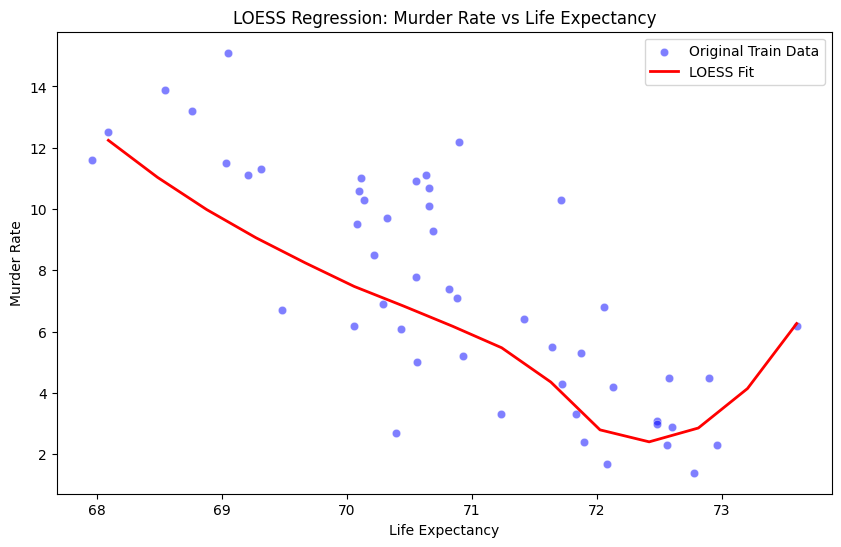

In [17]:
# Plot the original data and the LOESS fit
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=Y, label='Original Train Data', color='blue', alpha=0.5)
sns.lineplot(x=X_train_new, y=Y_new, label='LOESS Fit', color='red', linewidth=2)
plt.xlabel('Life Expectancy')
plt.ylabel('Murder Rate')
plt.title('LOESS Regression: Murder Rate vs Life Expectancy')
plt.legend()
plt.show()

In [18]:
pred_loess = loess(X_train, Y_train, eval_x=X_test, span=0.7, degree=2)

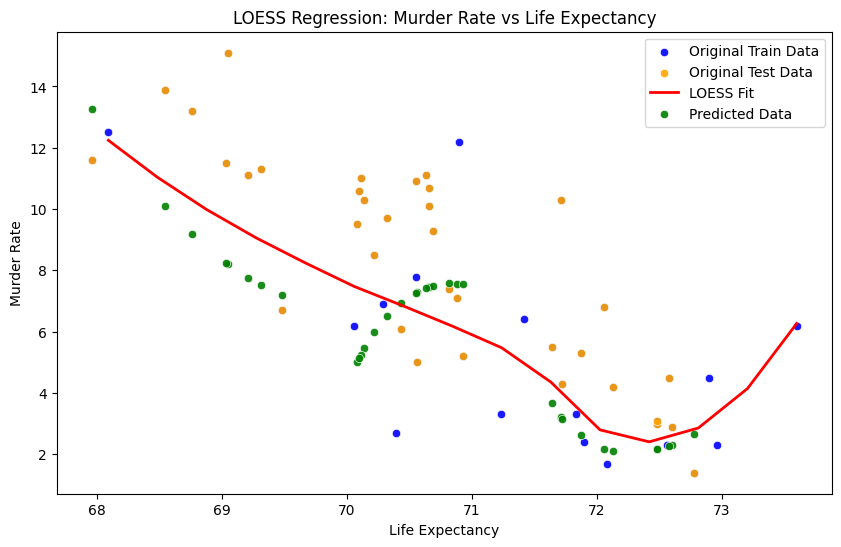

In [19]:
# Plot the original and predicted data and the LOESS fit
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=Y, label='Original Train Data', color='blue', alpha=0.9)
sns.scatterplot(x=X_test, y=Y_test, label='Original Test Data', color='orange', alpha=0.9)
sns.lineplot(x=X_train_new, y=Y_new, label='LOESS Fit', color='red', linewidth=2)
sns.scatterplot(x=X_test, y=pred_loess, label='Predicted Data', color='green', alpha=0.9)
plt.xlabel('Life Expectancy')
plt.ylabel('Murder Rate')
plt.title('LOESS Regression: Murder Rate vs Life Expectancy')
plt.legend()
plt.show()

Model evaluation

In [20]:
# Calculate MSE and R²
rmse = np.sqrt(mean_squared_error(Y_test, pred_loess))
r2 = r2_score(Y_test, pred_loess)

print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r2}')

Root Mean Squared Error (RMSE): 3.3623158714536316
R-squared (R²): 0.04984639667215618


###########################################################################################

Multiple Regression

Example 1

In [21]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [22]:
data = {
    'X1': [7, 9, 4, 2, 3, 1],
    'X2': [9, 8, 3, 3, 1, 1],
    'X3': [10, 8, 1, 2, 2, 1],
    'X4': [8, 10, 2, 2, 4, 4]
}
df = pd.DataFrame(data)
print(df)

   X1  X2  X3  X4
0   7   9  10   8
1   9   8   8  10
2   4   3   1   2
3   2   3   2   2
4   3   1   2   4
5   1   1   1   4


Scatter plots

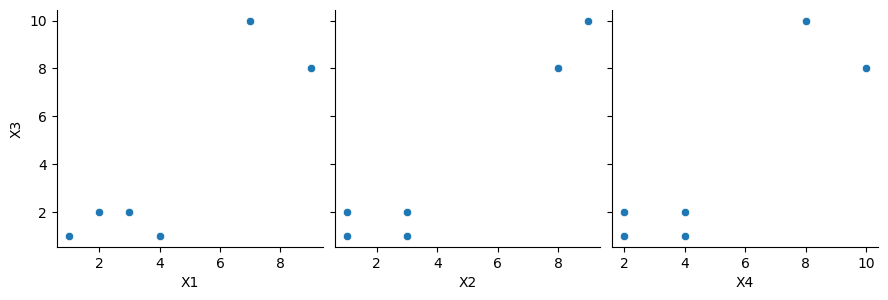

In [23]:
sns.pairplot(df, x_vars=['X1', 'X2', 'X4'], y_vars='X3', height=3, aspect=1, kind='scatter')
plt.show()

Correlation matrix

          X1        X2        X3        X4
X1  1.000000  0.906937  0.872258  0.870307
X2  0.906937  1.000000  0.958133  0.820031
X3  0.872258  0.958133  1.000000  0.893684
X4  0.870307  0.820031  0.893684  1.000000


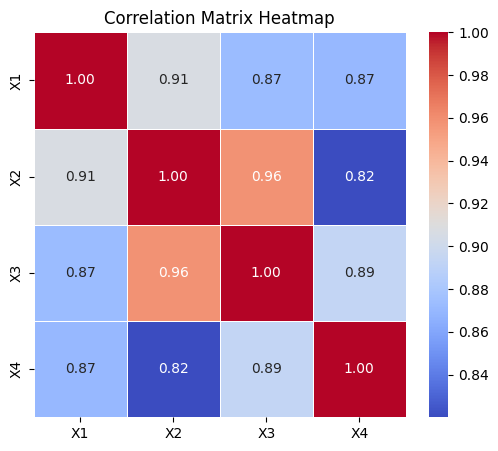

In [24]:
correlation_matrix = df.corr()
print(correlation_matrix)

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

Model creation

In [25]:
X = df[['X1', 'X2', 'X4']]
y = df['X3']

model = LinearRegression().fit(X, y)

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

Intercept: -1.0896130346232216
Coefficients: [-0.38391039  0.97861507  0.53513238]


Prediction and evaluation

In [26]:
# Předpověď pro nová data
new_data = np.array([[7, 9, 8]])  # Příklad hodnot
predicted = model.predict(new_data)
print('Predicted concentration ability score:', predicted)

# Hodnocení modelu
print('R^2 score:', model.score(X, y))

Predicted concentration ability score: [9.31160896]
R^2 score: 0.9651156718366494


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Evaluation of the model's coefficients

In [27]:
X = sm.add_constant(X)  # Přidá konstantní sloupec pro intercept
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     X3   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     18.44
Date:                Mon, 02 Mar 2026   Prob (F-statistic):             0.0519
Time:                        12:39:10   Log-Likelihood:                -6.1413
No. Observations:                   6   AIC:                             20.28
Df Residuals:                       2   BIC:                             19.45
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0896      0.942     -1.157      0.3

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Calculation of partial correlation coefficients

In [28]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 5.0 MB/s eta 0:00:00


In [29]:
import pingouin as pg

In [30]:
# Partial correlation between Y (X3) and X1 while controlling for the effect of X2 and X4
partial_corr_X1 = pg.partial_corr(data=df, x='X1', y='X3', covar=['X2', 'X4'])

# Partial correlation between Y (X3) and X2 while controlling for the effect of X1 and X4
partial_corr_X2 = pg.partial_corr(data=df, x='X2', y='X3', covar=['X1', 'X4'])

# Partial correlation between Y (X3) and X4 while controlling for the effect of X1 and X2
partial_corr_X4 = pg.partial_corr(data=df, x='X4', y='X3', covar=['X1', 'X2'])

print("Partial correlation between X3 and X1 while controlling for the effect of X2 and X4:\n", partial_corr_X1)
print("\nPartial correlation between X3 and X2 while controlling for the effect of X1 and X4:\n", partial_corr_X2)
print("\nPartial correlation between X3 and X4 while controlling for the effect of X1 and X2:\n", partial_corr_X4)


Partial correlation between X3 and X1 while controlling for the effect of X2 and X4:
          n        r           CI95    p_val
pearson  6 -0.49787  [-0.99, 0.89]  0.50213

Partial correlation between X3 and X2 while controlling for the effect of X1 and X4:
          n        r         CI95    p_val
pearson  6  0.88768  [-0.5, 1.0]  0.11232

Partial correlation between X3 and X4 while controlling for the effect of X1 and X2:
          n         r           CI95     p_val
pearson  6  0.757737  [-0.75, 0.99]  0.242263


Example 2

In [31]:
from sklearn.datasets import make_regression

Generate sinthetic data

In [32]:
n_samples = 200
n_features = 3
n_informative = 3
n_targets = 1
noise = 0.05

X, y, coef = make_regression(
    n_samples=n_samples, n_features=n_features, n_informative=n_informative,
    n_targets=n_targets, noise=noise, coef=True, random_state=42
)

df = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(n_features)])
df['Y'] = y

print(df.head())

         X1        X2        X3           Y
0  0.130741 -1.430141 -0.440044  -55.201738
1  1.502357 -0.269407  0.717542  153.828447
2  0.647689  0.496714 -0.138264   48.106303
3  0.341756 -0.759133  0.150394   18.058782
4  0.856399 -1.514847 -0.446515   -5.446866


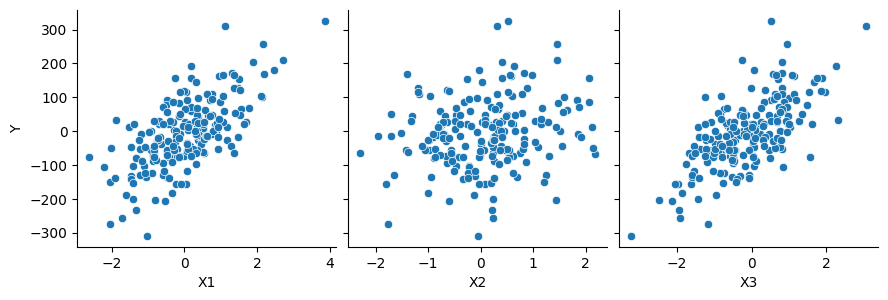

In [33]:
sns.pairplot(df, x_vars=['X1', 'X2', 'X3'], y_vars='Y',
             height=3, aspect=1, kind='scatter')
plt.show()

Correlation analysis

          X1        X2        X3         Y
X1  1.000000 -0.057555 -0.068706  0.658446
X2 -0.057555  1.000000  0.035173  0.187290
X3 -0.068706  0.035173  1.000000  0.677798
Y   0.658446  0.187290  0.677798  1.000000


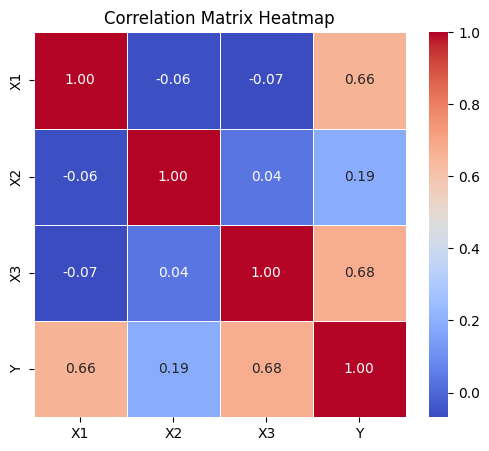

In [34]:
correlation_matrix = df.corr()
print(correlation_matrix)

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

Partial correlation coefficients

In [35]:
# Partial correlation between Y (X3) and X1 while controlling for the effect of X2 and X4
partial_corr_X1 = pg.partial_corr(data=df, x='X1', y='Y', covar=['X2', 'X3'])

# Partial correlation between Y (X3) and X2 while controlling for the effect of X1 and X4
partial_corr_X2 = pg.partial_corr(data=df, x='X2', y='Y', covar=['X1', 'X3'])

# Partial correlation between Y (X3) and X3 while controlling for the effect of X1 and X2
partial_corr_X3 = pg.partial_corr(data=df, x='X3', y='Y', covar=['X1', 'X2'])

print("Partial correlation between Y and X1 while controlling for the effect of X2 and X3:\n", partial_corr_X1)
print("\nPartial correlation between Y and X2 while controlling for the effect of X1 and X3:\n", partial_corr_X2)
print("\nPartial correlation between Y and X3 while controlling for the effect of X1 and X2:\n", partial_corr_X3)


Partial correlation between Y and X1 while controlling for the effect of X2 and X3:
            n    r        CI95  p_val
pearson  200  1.0  [1.0, 1.0]    0.0

Partial correlation between Y and X2 while controlling for the effect of X1 and X3:
            n         r        CI95  p_val
pearson  200  0.999997  [1.0, 1.0]    0.0

Partial correlation between Y and X3 while controlling for the effect of X1 and X2:
            n    r        CI95  p_val
pearson  200  1.0  [1.0, 1.0]    0.0


Model creation

In [36]:
X = df[['X1', 'X2', 'X3']]
y = df['Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creating and training the model
model = LinearRegression().fit(X_train, y_train)


Model evaluation

In [37]:
# Prediction and model evaluation
y_pred = model.predict(X_test)
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

# Výpis koeficientů
print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

MSE: 0.0032573621592414024
R2 score: 0.9999996674589219
Intercept: -0.002980610440125986
Coefficients: [72.00485408 22.92465847 72.22707527]


In [38]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.427e+08
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:45:33   Log-Likelihood:                 307.13
No. Observations:                 200   AIC:                            -606.3
Df Residuals:                     196   BIC:                            -593.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0018      0.004     -0.487      0.6

Example 3

In [40]:
file_path = '/content/drive/MyDrive/2025_2026/PSM/Regression_2/mtcars.csv'

mtcars_Data = pd.read_csv(file_path)
print(mtcars_Data.head(10))
print(mtcars_Data.info())
print(mtcars_Data.describe())

    mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  carb
0  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4     4
1  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4     4
2  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4     1
3  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3     1
4  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3     2
5  18.1    6  225.0  105  2.76  3.460  20.22   1   0     3     1
6  14.3    8  360.0  245  3.21  3.570  15.84   0   0     3     4
7  24.4    4  146.7   62  3.69  3.190  20.00   1   0     4     2
8  22.8    4  140.8   95  3.92  3.150  22.90   1   0     4     2
9  19.2    6  167.6  123  3.92  3.440  18.30   1   0     4     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float

In [41]:
mtcars_short = mtcars_Data.iloc[:, [0,2,3,4,5,6]]
print(mtcars_short.head(10))

    mpg   disp   hp  drat     wt   qsec
0  21.0  160.0  110  3.90  2.620  16.46
1  21.0  160.0  110  3.90  2.875  17.02
2  22.8  108.0   93  3.85  2.320  18.61
3  21.4  258.0  110  3.08  3.215  19.44
4  18.7  360.0  175  3.15  3.440  17.02
5  18.1  225.0  105  2.76  3.460  20.22
6  14.3  360.0  245  3.21  3.570  15.84
7  24.4  146.7   62  3.69  3.190  20.00
8  22.8  140.8   95  3.92  3.150  22.90
9  19.2  167.6  123  3.92  3.440  18.30


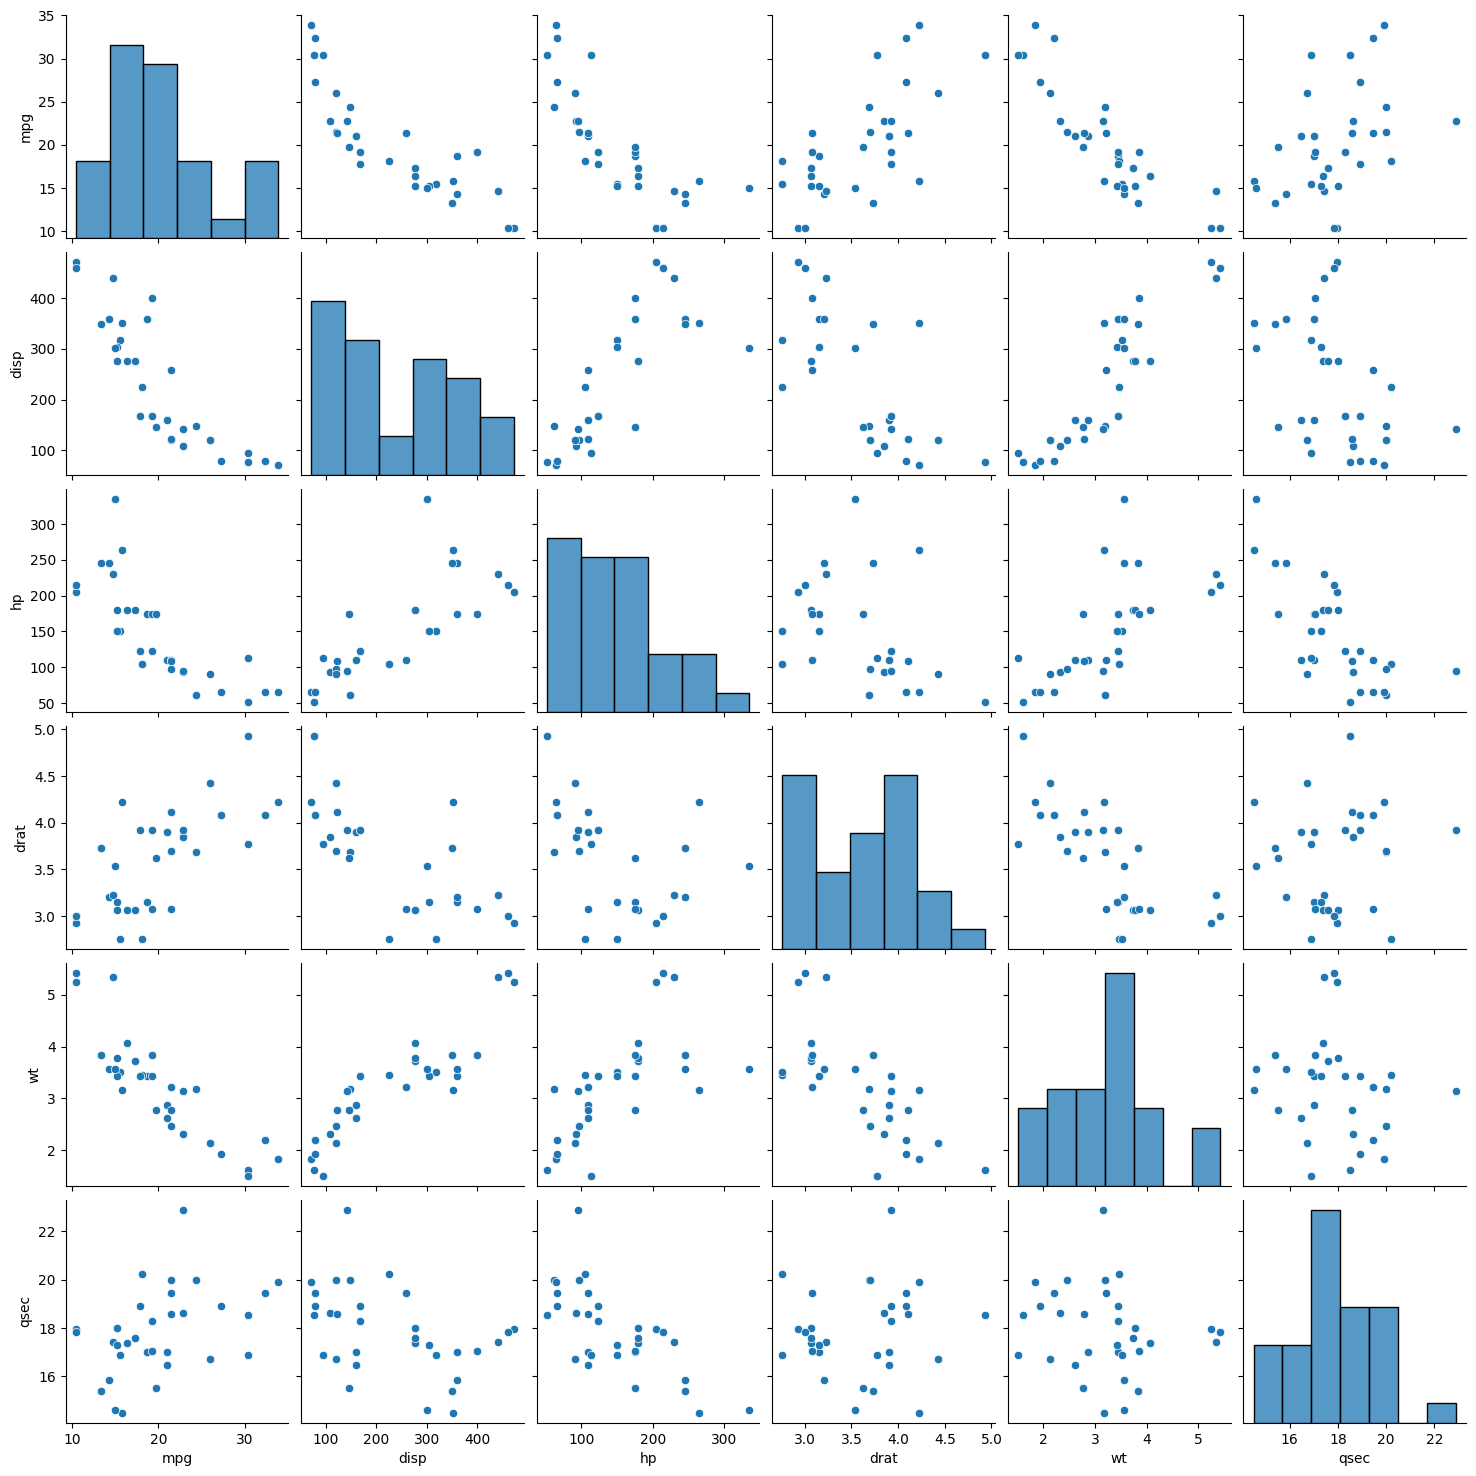

In [42]:
sns.pairplot(mtcars_short)
plt.show()

           mpg      disp        hp      drat        wt      qsec
mpg   1.000000 -0.847551 -0.776168  0.681172 -0.867659  0.418684
disp -0.847551  1.000000  0.790949 -0.710214  0.887980 -0.433698
hp   -0.776168  0.790949  1.000000 -0.448759  0.658748 -0.708223
drat  0.681172 -0.710214 -0.448759  1.000000 -0.712441  0.091205
wt   -0.867659  0.887980  0.658748 -0.712441  1.000000 -0.174716
qsec  0.418684 -0.433698 -0.708223  0.091205 -0.174716  1.000000


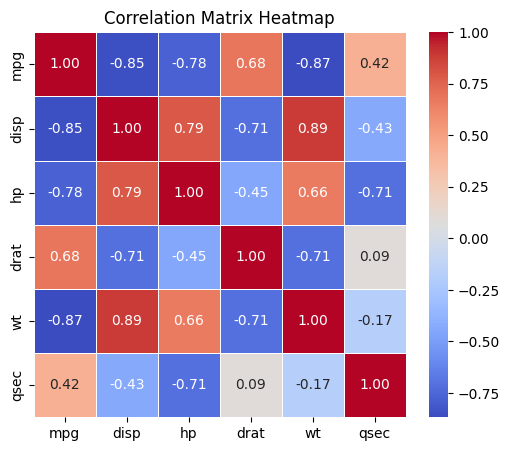

In [43]:
correlation_matrix = mtcars_short.corr()
print(correlation_matrix)

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

Apply box plots to visualize the distribution of the attributes' values

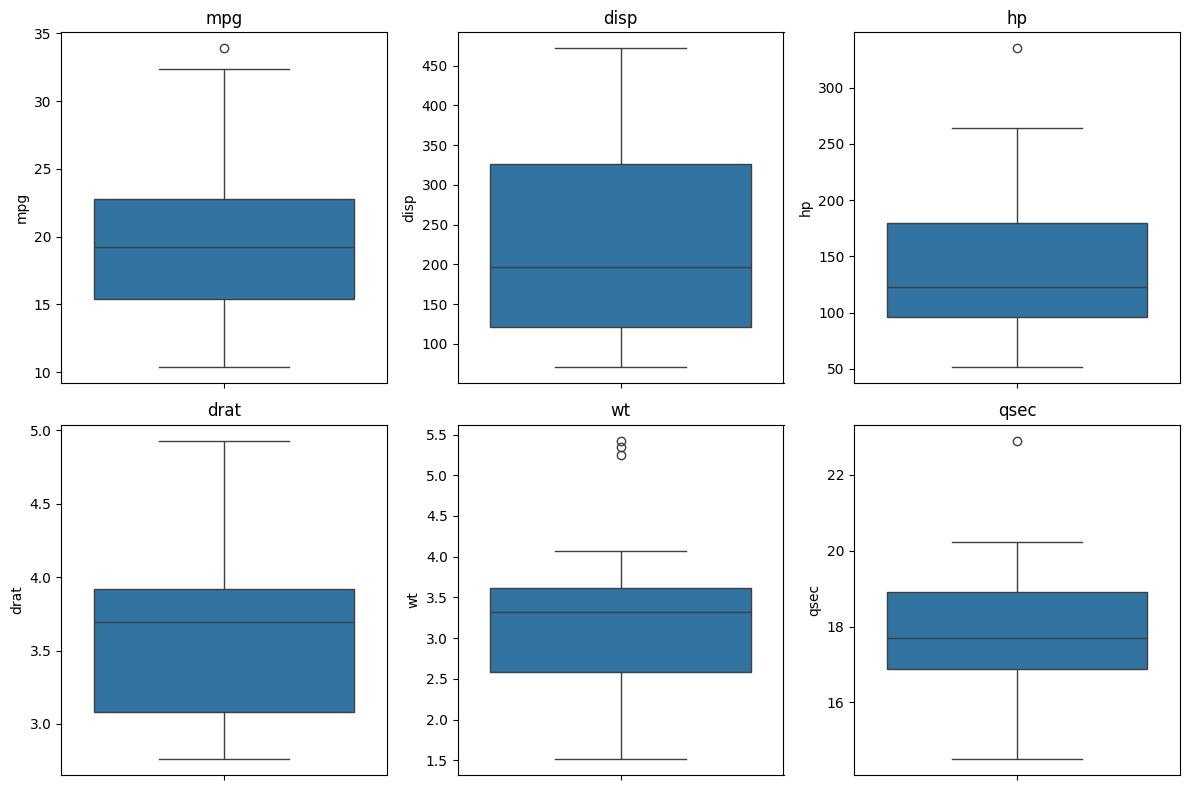

In [44]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))  # 2 rows, 3 columns

# Plotting each variable in a separate subplot
sns.boxplot(data=mtcars_short['mpg'], ax=axs[0, 0]).set_title('mpg')
sns.boxplot(data=mtcars_short['disp'], ax=axs[0, 1]).set_title('disp')
sns.boxplot(data=mtcars_short['hp'], ax=axs[0, 2]).set_title('hp')
sns.boxplot(data=mtcars_short['drat'], ax=axs[1, 0]).set_title('drat')
sns.boxplot(data=mtcars_short['wt'], ax=axs[1, 1]).set_title('wt')
sns.boxplot(data=mtcars_short['qsec'], ax=axs[1, 2]).set_title('qsec')

plt.tight_layout()
plt.show()

Data normalization

In [45]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [46]:
X = mtcars_short.drop('mpg', axis=1)


# Normalizing using Min-Max scaling
min_max_scaler = MinMaxScaler()
X_minmax = min_max_scaler.fit_transform(X)

# Normalizing using Standardization
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

# Converting back to DataFrame for easier viewing
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)
X_std_df = pd.DataFrame(X_std, columns=X.columns)

# Showing the first few rows of the normalized data for comparison
X_minmax_df.describe(), X_std_df.describe()

(            disp         hp       drat         wt       qsec
 count  32.000000  32.000000  32.000000  32.000000  32.000000
 mean    0.398159   0.334585   0.385513   0.435758   0.398661
 std     0.309151   0.242272   0.246396   0.250181   0.212731
 min     0.000000   0.000000   0.000000   0.000000   0.000000
 25%     0.124033   0.157244   0.147465   0.273140   0.284821
 50%     0.312297   0.250883   0.430876   0.463309   0.382143
 75%     0.635819   0.452297   0.534562   0.536180   0.523810
 max     1.000000   1.000000   1.000000   1.000000   1.000000,
                disp         hp          drat            wt          qsec
 count  3.200000e+01  32.000000  3.200000e+01  3.200000e+01  3.200000e+01
 mean   1.665335e-16   0.000000 -3.053113e-16 -4.718448e-16 -1.471046e-15
 std    1.016001e+00   1.016001  1.016001e+00  1.016001e+00  1.016001e+00
 min   -1.308518e+00  -1.403130 -1.589643e+00 -1.769642e+00 -1.903996e+00
 25%   -9.008917e-01  -0.743705 -9.815764e-01 -6.604034e-01 -5.436944e-

In [47]:
X_minmax_df['mpg'] = mtcars_short['mpg']
X_std_df['mpg'] = mtcars_short['mpg']
print(X_minmax_df.head())
print(X_std_df.head())

       disp        hp      drat        wt      qsec   mpg
0  0.221751  0.204947  0.525346  0.283048  0.233333  21.0
1  0.221751  0.204947  0.525346  0.348249  0.300000  21.0
2  0.092043  0.144876  0.502304  0.206341  0.489286  22.8
3  0.466201  0.204947  0.147465  0.435183  0.588095  21.4
4  0.720629  0.434629  0.179724  0.492713  0.300000  18.7
       disp        hp      drat        wt      qsec   mpg
0 -0.579750 -0.543655  0.576594 -0.620167 -0.789601  21.0
1 -0.579750 -0.543655  0.576594 -0.355382 -0.471202  21.0
2 -1.006026 -0.795570  0.481584 -0.931678  0.432823  22.8
3  0.223615 -0.543655 -0.981576 -0.002336  0.904736  21.4
4  1.059772  0.419550 -0.848562  0.231297 -0.471202  18.7


Calculate the partial correlation coefficients

In [48]:
# Partial correlation between mpg and disp while controlling for hp, drat, wt, and qsec
partial_corr_disp = pg.partial_corr(data=X_std_df, x='disp', y='mpg', covar=['hp', 'drat', 'wt', 'qsec'])
print("Partial correlation between mpg and disp:\n", partial_corr_disp)

# Partial correlation between mpg and hp while controlling for disp, drat, wt, and qsec
partial_corr_hp = pg.partial_corr(data=X_std_df, x='hp', y='mpg', covar=['disp', 'drat', 'wt', 'qsec'])
print("Partial correlation between mpg and hp:\n", partial_corr_hp)

# Partial correlation between mpg and drat while controlling for disp, hp, wt, and qsec
partial_corr_drat = pg.partial_corr(data=X_std_df, x='drat', y='mpg', covar=['disp', 'hp', 'wt', 'qsec'])
print("Partial correlation between mpg and drat:\n", partial_corr_drat)

# Partial correlation between mpg and wt while controlling for disp, hp, drat, and qsec
partial_corr_wt = pg.partial_corr(data=X_std_df, x='wt', y='mpg', covar=['disp', 'hp', 'drat', 'qsec'])
print("Partial correlation between mpg and wt:\n", partial_corr_wt)

# Partial correlation between mpg and qsec while controlling for disp, hp, drat, and wt
partial_corr_qsec = pg.partial_corr(data=X_std_df, x='qsec', y='mpg', covar=['disp', 'hp', 'drat', 'wt'])
print("Partial correlation between mpg and qsec:\n", partial_corr_qsec)


Partial correlation between mpg and disp:
           n         r          CI95     p_val
pearson  32  0.151088  [-0.24, 0.5]  0.442812
Partial correlation between mpg and hp:
           n         r           CI95    p_val
pearson  32 -0.255543  [-0.57, 0.13]  0.18936
Partial correlation between mpg and drat:
           n         r          CI95     p_val
pearson  32  0.289016  [-0.09, 0.6]  0.135791
Partial correlation between mpg and wt:
           n         r            CI95     p_val
pearson  32 -0.568862  [-0.78, -0.25]  0.001584
Partial correlation between mpg and qsec:
           n         r           CI95     p_val
pearson  32  0.263641  [-0.12, 0.58]  0.175233


Model creation

In [49]:
X = X_std_df[['disp', 'hp', 'drat','wt','qsec']]
y = X_std_df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression().fit(X_train, y_train)

y_pred = model.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 index:', r2_score(y_test, y_pred))

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

RMSE: 2.584395351109756
R2 index: 0.8034755582182798
Intercept: 19.70796556530539
Coefficients: [ 1.63083222 -2.1040575   1.36685981 -4.01013685  1.22200656]


PCA implementation

In [50]:
from sklearn.decomposition import PCA

In [51]:
pca = PCA()
pca.fit(X)

PCA()

In [52]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Printing explained variance ratio for each component
print("Explained Variance Ratio for each component:", explained_variance_ratio)
print("Cumulative Explained Variance:", cumulative_explained_variance)

Explained Variance Ratio for each component: [0.6677492  0.2286689  0.06480448 0.02508475 0.01369267]
Cumulative Explained Variance: [0.6677492  0.8964181  0.96122258 0.98630733 1.        ]


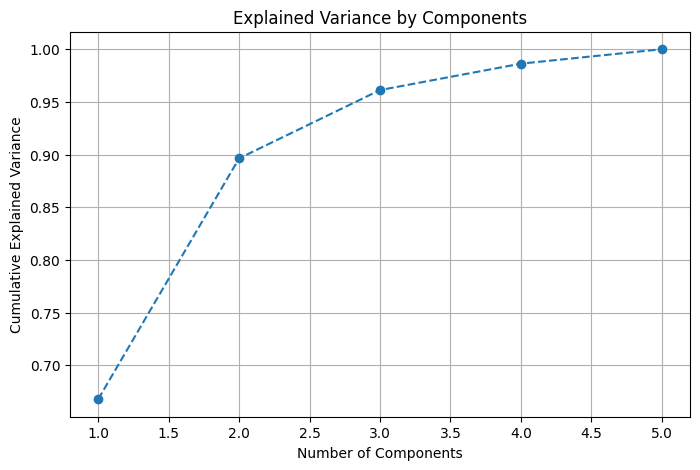

In [53]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [54]:
# Applying PCA with only the two principal components
pca_1 = PCA(n_components=2)
X_pca_1 = pca_1.fit_transform(X)

# Creating a new DataFrame for the transformed data
X_pca_1_df = pd.DataFrame(X_pca_1, columns=['PC1','PC2'])

new_data = pd.DataFrame({
    'PC1': X_pca_1_df['PC1'],
    'PC2': X_pca_1_df['PC2'],
    'Target': X_std_df['mpg']
})
print(new_data)

         PC1       PC2  Target
0  -0.870610 -0.918568    21.0
1  -0.836889 -0.594994    21.0
2  -1.689696 -0.006243    22.8
3  -0.009893  1.333596    21.4
4   1.360380  0.055480    18.7
5   0.053662  2.028710    18.1
6   2.077826 -0.812373    14.3
7  -1.416763  1.198781    24.4
8  -1.893854  2.052603    22.8
9  -0.658636  0.060732    19.2
10 -0.759573  0.316999    17.8
11  1.347446  0.411751    16.4
12  1.143229  0.384652    17.3
13  1.101021  0.572044    15.2
14  2.976634  1.182362    10.4
15  3.055885  1.051611    10.4
16  2.924815  0.564391    14.7
17 -2.393789  0.237416    32.4
18 -3.304622 -1.033192    30.4
19 -2.798568  0.178138    33.9
20 -1.654460  0.758497    21.5
21  1.370438  0.454756    15.5
22  0.890341  0.260934    15.2
23  1.836193 -1.366420    13.3
24  1.785806  0.291232    19.2
25 -2.429550 -0.093530    27.3
26 -1.873062 -1.367864    26.0
27 -1.657015 -1.044367    30.4
28  1.410511 -2.499021    15.8
29 -0.014983 -1.374958    19.7
30  2.417636 -2.126523    15.0
31 -1.48

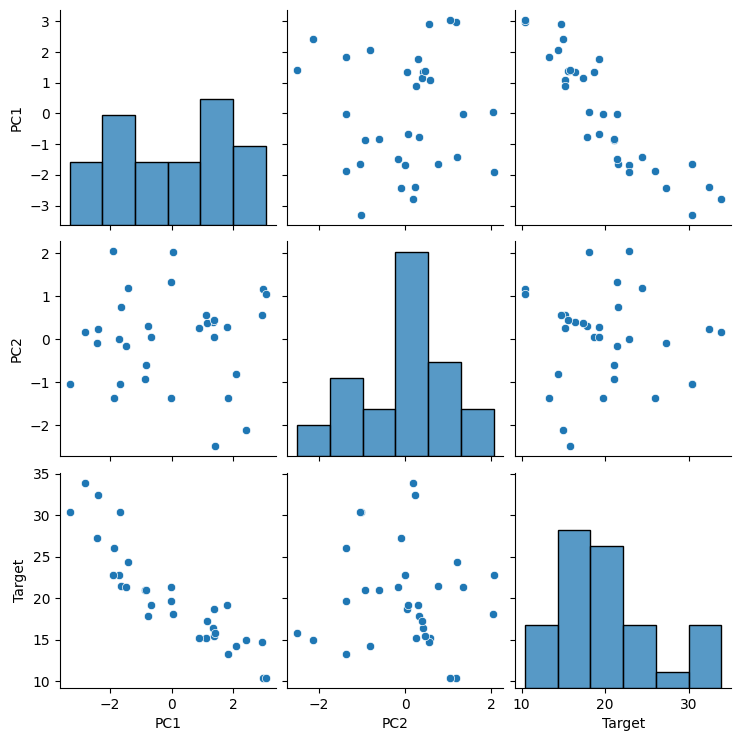

In [55]:
sns.pairplot(new_data)
plt.show()

                 PC1           PC2    Target
PC1     1.000000e+00  5.194047e-17 -0.899652
PC2     5.194047e-17  1.000000e+00 -0.075784
Target -8.996516e-01 -7.578391e-02  1.000000


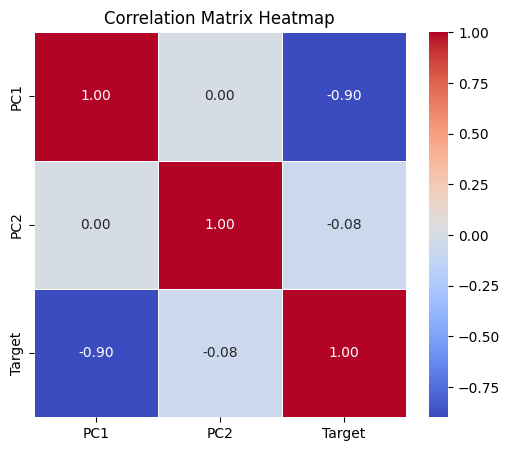

In [56]:
correlation_matrix = new_data.corr()
print(correlation_matrix)

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [57]:
X_new = new_data[['PC1', 'PC2']]
y_new = new_data['Target']

X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

# Creating and training the model
model = LinearRegression().fit(X_train, y_train)

# Prediction and model evaluation
y_pred = model.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 score:', r2_score(y_test, y_pred))

RMSE: 2.6459500123753816
R2 score: 0.794002504906733


In [ ]:
X_new = sm.add_constant(X_new)
model = sm.OLS(y_new, X_new).fit()

print(model.summary())

Polynomial multiple regression

In [58]:
from sklearn.preprocessing import PolynomialFeatures

In [59]:
# Polynomial transformation for 'disp' and 'hp'
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X[['disp', 'hp']])

# Combine polynomial features with linear features ('drat', 'wt', 'qsec')
X_combined = np.hstack((X_poly, X[['drat', 'wt', 'qsec']].values))

# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)


# Creating and training the multiple regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting test set results
y_pred = model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('R2 skóre:', r2)

print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

MSE: 13.757387192501977
R2 skóre: 0.595205475400179
Intercept: 17.44907640457678
Coefficients: [-0.55721302 -3.15478336 -0.5913525   4.88389076 -1.19501858 -0.83405296
 -3.5655367  -0.29373115]
